# Check synchronization of mocap data with drone data

## 1. Set up notebook

Do imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ae483.tools import *
from ae483.mytools import *

## 2. Check force data

Load flight data.

In [2]:
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('force_data.json')

Resample drone data.

In [16]:
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=5., # <-- FIXME
    t_max_offset=3., # <-- FIXME
)

t = data_drone['time']
x_drone = data_drone['stateEstimate.x']
y_drone = data_drone['stateEstimate.y']
z_drone = data_drone['stateEstimate.z']
psi_drone = np.deg2rad(data_drone['stateEstimate.yaw'])
theta_drone = - np.deg2rad(data_drone['stateEstimate.pitch'])
phi_drone = np.deg2rad(data_drone['stateEstimate.roll'])

Resample mocap data (with an optimal time shift and with coordinate transformation).

In [17]:
data_mocap = sync_data_mocap(
    raw_data_mocap,
    t,
    z_drone,
    do_transform=True,      # <-- whether to align mocap data in space
    t_min_offset=0.,        # <-- how many seconds of mocap data to delete at the start
    t_shift_rng=1.,         # <-- range of time shifts over which to search
    t_shift_res=0.05,       # <-- resolution at which to sample time shifts in the range
)

x_mocap = data_mocap['x']
y_mocap = data_mocap['y']
z_mocap = data_mocap['z']
psi_mocap = data_mocap['yaw']
theta_mocap = data_mocap['pitch']
phi_mocap = data_mocap['roll']

Plot $x, y$ data.

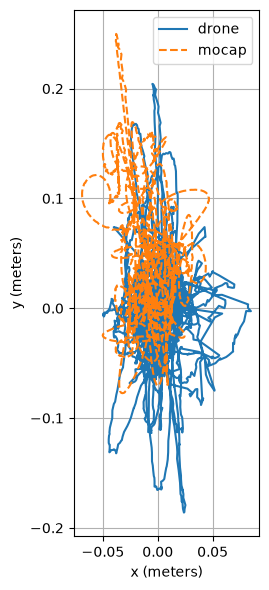

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), tight_layout=True)
ax.plot(x_drone, y_drone, label='drone')
ax.plot(x_mocap, y_mocap, '--', label='mocap')
ax.set_aspect('equal')
ax.set_xlabel('x (meters)')
ax.set_ylabel('y (meters)')
ax.legend()
ax.grid()

Plot all data.

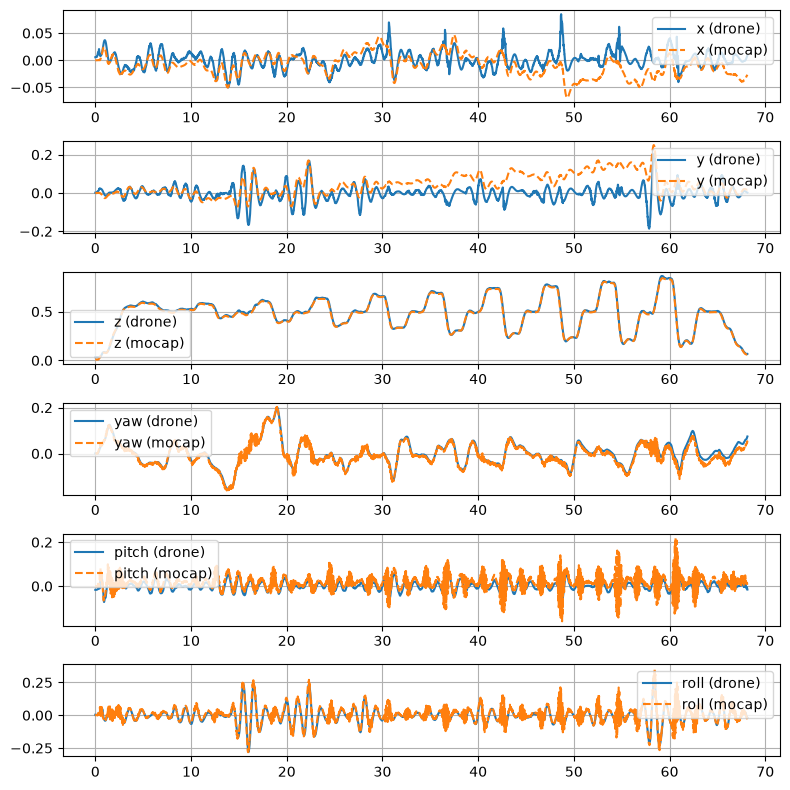

In [19]:
fig, (ax_x, ax_y, ax_z, ax_psi, ax_theta, ax_phi) = plt.subplots(6, 1, figsize=(8, 8), tight_layout=True)

ax_x.plot(t, x_drone, label='x (drone)')
ax_x.plot(t, x_mocap, '--', label='x (mocap)')
ax_x.legend()
ax_x.grid()

ax_y.plot(t, y_drone, label='y (drone)')
ax_y.plot(t, y_mocap, '--', label='y (mocap)')
ax_y.legend()
ax_y.grid()

ax_z.plot(t, z_drone, label='z (drone)')
ax_z.plot(t, z_mocap, '--', label='z (mocap)')
ax_z.legend()
ax_z.grid()

ax_psi.plot(t, psi_drone, label='yaw (drone)')
ax_psi.plot(t, psi_mocap, '--', label='yaw (mocap)')
ax_psi.legend()
ax_psi.grid()

ax_theta.plot(t, theta_drone, label='pitch (drone)')
ax_theta.plot(t, theta_mocap, '--', label='pitch (mocap)')
ax_theta.legend()
ax_theta.grid()

ax_phi.plot(t, phi_drone, label='roll (drone)')
ax_phi.plot(t, phi_mocap, '--', label='roll (mocap)')
ax_phi.legend()
ax_phi.grid()

## 3. Check moment data

**FIXME** Add cells to check `moment_data.json` in exactly the same way.

In [23]:
raw_data_drone_m, raw_data_mocap_m, raw_data_bodies_m = load_hardware_data('moment_data.json')

In [24]:
data_drone_m = resample_data_drone(
    raw_data_drone_m,
    t_min_offset=5., # <-- FIXME
    t_max_offset=3., # <-- FIXME
)

t_m = data_drone_m['time']
x_drone_m = data_drone_m['stateEstimate.x']
y_drone_m = data_drone_m['stateEstimate.y']
z_drone_m = data_drone_m['stateEstimate.z']
psi_drone_m = np.deg2rad(data_drone_m['stateEstimate.yaw'])
theta_drone_m = - np.deg2rad(data_drone_m['stateEstimate.pitch'])
phi_drone_m = np.deg2rad(data_drone_m['stateEstimate.roll'])

In [25]:
data_mocap_m = sync_data_mocap(
    raw_data_mocap_m,
    t_m,
    z_drone_m,
    do_transform=True,      # <-- whether to align mocap data in space
    t_min_offset=0.,        # <-- how many seconds of mocap data to delete at the start
    t_shift_rng=1.,         # <-- range of time shifts over which to search
    t_shift_res=0.05,       # <-- resolution at which to sample time shifts in the range
)

x_mocap_m = data_mocap_m['x']
y_mocap_m = data_mocap_m['y']
z_mocap_m = data_mocap_m['z']
psi_mocap_m = data_mocap_m['yaw']
theta_mocap_m = data_mocap_m['pitch']
phi_mocap_m = data_mocap_m['roll']

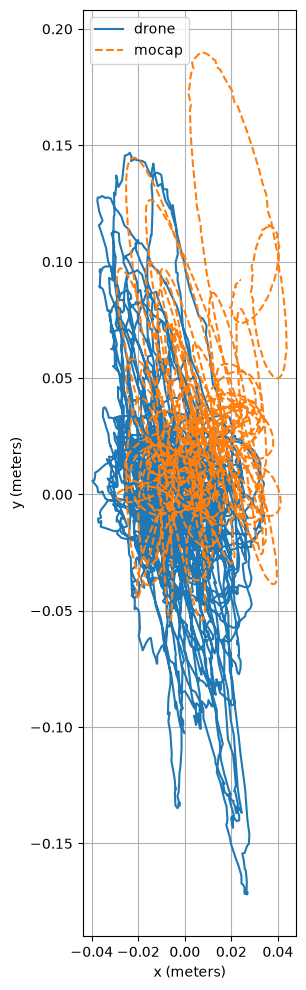

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), tight_layout=True)
ax.plot(x_drone_m, y_drone_m, label='drone')
ax.plot(x_mocap_m, y_mocap_m, '--', label='mocap')
ax.set_aspect('equal')
ax.set_xlabel('x (meters)')
ax.set_ylabel('y (meters)')
ax.legend()
ax.grid()

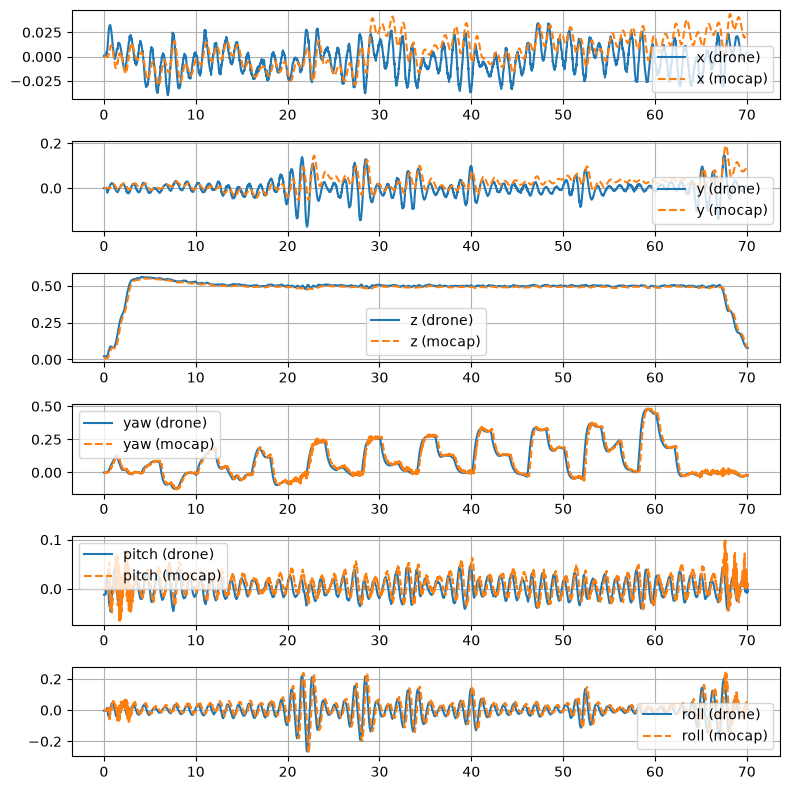

In [28]:
fig, (ax_x, ax_y, ax_z, ax_psi, ax_theta, ax_phi) = plt.subplots(6, 1, figsize=(8, 8), tight_layout=True)

ax_x.plot(t_m, x_drone_m, label='x (drone)')
ax_x.plot(t_m, x_mocap_m, '--', label='x (mocap)')
ax_x.legend()
ax_x.grid()

ax_y.plot(t_m, y_drone_m, label='y (drone)')
ax_y.plot(t_m, y_mocap_m, '--', label='y (mocap)')
ax_y.legend()
ax_y.grid()

ax_z.plot(t_m, z_drone_m, label='z (drone)')
ax_z.plot(t_m, z_mocap_m, '--', label='z (mocap)')
ax_z.legend()
ax_z.grid()

ax_psi.plot(t_m, psi_drone_m, label='yaw (drone)')
ax_psi.plot(t_m, psi_mocap_m, '--', label='yaw (mocap)')
ax_psi.legend()
ax_psi.grid()

ax_theta.plot(t_m, theta_drone_m, label='pitch (drone)')
ax_theta.plot(t_m, theta_mocap_m, '--', label='pitch (mocap)')
ax_theta.legend()
ax_theta.grid()

ax_phi.plot(t_m, phi_drone_m, label='roll (drone)')
ax_phi.plot(t_m, phi_mocap_m, '--', label='roll (mocap)')
ax_phi.legend()
ax_phi.grid()